In [1]:
# connecting the sagemaker to s3
import boto3
import sagemaker
import pandas as pd

role = sagemaker.get_execution_role()

bucket = 'aws-customer-churn-prediction'
file_name = 'train.csv'

data_location = f's3://{bucket}/{file_name}'

Unable to load JumpStart region config.
Traceback (most recent call last):
  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sagemaker/jumpstart/constants.py", line 69, in _load_region_config
    with open(filepath) as f:
         ^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sagemaker/jumpstart/region_config.json'


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [19]:
df_train = pd.read_csv(data_location)

df_train.head()

,Customer_ID,Name,Email,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn
0,a8b2ac22-dd31-483e-8672-592b7089138f,Brenda Grant,dhanson@example.com,790,Weekly,28,Just checking if my payment went through.,0
1,320c00d8-9b88-44f6-ab57-d46976740ca1,Christopher Wells,awatts@example.net,399,Daily,28,Just checking if my payment went through.,1
2,0c6e183c-4af4-4062-b0aa-875f47a0e0d1,Robert Raymond,medinaerika@example.org,646,Daily,110,The integration with Slack works perfectly.,0
3,c4cf3a80-cbbe-47c5-8340-ef8d149607a7,Glenda Irwin,aramirez@example.org,113,Weekly,21,Just checking if my payment went through.,0
4,366001d6-9bec-4667-b80c-18045a682f7f,Alyssa Luna,bergeramanda@example.org,322,Weekly,7,Your API documentation is outdated and full of...,1


In [3]:
# checking the null values

print(f'Missing values count: \n{df_train.isnull().sum()}')

Missing values count: 
Customer_ID            0
Name                   0
Email                  0
Account_Age_Days       0
Login_Frequency        0
Daily_Usage_Mins       0
Last_Support_Ticket    0
Churn                  0
dtype: int64


In [4]:
# Grab the universal remote control for Comprehend
comprehend = boto3.client('comprehend', region_name='us-east-1') 

# Extracting the first support ticket from our 'Last_Support_Ticket' column
sample_ticket = df_train['Last_Support_Ticket'].iloc[0]
print(f"Original Ticket Text: '{sample_ticket}'\n")

# Sending the text to the AI and ask for the sentiment
response = comprehend.detect_sentiment(Text=sample_ticket, LanguageCode='en')

# Print out the AI's final answer
print(f"AI Predicted Sentiment: {response['Sentiment']}")
print(f"Confidence Scores: {response['SentimentScore']}")

Original Ticket Text: 'Just checking if my payment went through.'

AI Predicted Sentiment: NEUTRAL
Confidence Scores: {'Positive': 0.002615896752104163, 'Negative': 0.021660391241312027, 'Neutral': 0.9697326421737671, 'Mixed': 0.0059911892749369144}


In [5]:
def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return "NEUTRAL"

    response = comprehend.detect_sentiment(Text=text, LanguageCode='en')
    return response['Sentiment']

In [6]:
df_train['Sentiment'] = df_train['Last_Support_Ticket'].apply(get_sentiment)

df_train.head()

,Customer_ID,Name,Email,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn,Sentiment
0,a8b2ac22-dd31-483e-8672-592b7089138f,Brenda Grant,dhanson@example.com,790,Weekly,28,Just checking if my payment went through.,0,NEUTRAL
1,320c00d8-9b88-44f6-ab57-d46976740ca1,Christopher Wells,awatts@example.net,399,Daily,28,Just checking if my payment went through.,1,NEUTRAL
2,0c6e183c-4af4-4062-b0aa-875f47a0e0d1,Robert Raymond,medinaerika@example.org,646,Daily,110,The integration with Slack works perfectly.,0,POSITIVE
3,c4cf3a80-cbbe-47c5-8340-ef8d149607a7,Glenda Irwin,aramirez@example.org,113,Weekly,21,Just checking if my payment went through.,0,NEUTRAL
4,366001d6-9bec-4667-b80c-18045a682f7f,Alyssa Luna,bergeramanda@example.org,322,Weekly,7,Your API documentation is outdated and full of...,1,NEGATIVE


In [7]:
# Defining our translation dictionary based on your exact numbers
sentiment_mapping = {
    'POSITIVE': 1,
    'NEUTRAL': 0,
    'NEGATIVE': -1,
    'MIXED': 0  # Comprehend sometimes returns MIXED 
}

login_mapping= {
    'Daily' : 2,
    'Weekly' : 1,
    'Monthly': 0,
    'Rerely': 0
}

# Mapping text to numbers and save it in a new column
df_train['Sentiment_Score'] = df_train['Sentiment'].map(sentiment_mapping)
df_train['Login_Frequency'] = df_train['Login_Frequency'].map(login_mapping)

# Looking the two columns side-by-side to verify the translation
print(f'{df_train[['Sentiment', 'Sentiment_Score']].head(10)}')
print(f'{df_train[['Login_Frequency']].head()}')

  Sentiment  Sentiment_Score
0   NEUTRAL                0
1   NEUTRAL                0
2  POSITIVE                1
3   NEUTRAL                0
4  NEGATIVE               -1
5   NEUTRAL                0
6  NEGATIVE               -1
7   NEUTRAL                0
8   NEUTRAL                0
9   NEUTRAL                0
   Login_Frequency
0              1.0
1              2.0
2              2.0
3              1.0
4              1.0


In [8]:
# Define the columns we want to throw away
columns_to_drop = ['Customer_ID', 'Name', 'Email', 'Last_Support_Ticket', 'Sentiment']

# Dropping the columns from our training data
df_train_clean = df_train.drop(columns_to_drop, axis=1)

df_train_clean.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn,Sentiment_Score
0,790,1.0,28,0,0
1,399,2.0,28,1,0
2,646,2.0,110,0,1
3,113,1.0,21,0,0
4,322,1.0,7,1,-1


In [9]:
# Define the columns we want to throw away
columns_to_drop = ['Customer_ID', 'Name', 'Email', 'Last_Support_Ticket', 'Sentiment']

# Dropping the columns from our training data
df_train_clean = df_train.drop(columns_to_drop, axis=1)

# fill NAN values as 0 
df_train_clean = df_train_clean.fillna(0)

df_train_clean.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn,Sentiment_Score
0,790,1.0,28,0,0
1,399,2.0,28,1,0
2,646,2.0,110,0,1
3,113,1.0,21,0,0
4,322,1.0,7,1,-1


In [10]:
# Define the target
y = df_train_clean['Churn']

# Define the features  by dropping the target from the table
X = df_train_clean.drop('Churn', axis=1)

# Let's verify our shapes to make sure they match!
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

X.head()

Features (X) shape: (2000, 4)
Target (y) shape: (2000,)


,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Sentiment_Score
0,790,1.0,28,0
1,399,2.0,28,0
2,646,2.0,110,1
3,113,1.0,21,0
4,322,1.0,7,-1


In [11]:
# Load the test data
test_file_name = 'test_.csv' 
test_data_location = f's3://{bucket}/{test_file_name}'
df_test = pd.read_csv(test_data_location)

#  Run the AI Sentiment Analysis on the test tickets
df_test['Sentiment'] = df_test['Last_Support_Ticket'].apply(get_sentiment)

# Apply your numerical mappings
df_test['Sentiment_Score'] = df_test['Sentiment'].map(sentiment_mapping)
df_test['Login_Frequency'] = df_test['Login_Frequency'].map(login_mapping)

# Drop the same non-numerical columns we dropped before
df_test_clean = df_test.drop(['Customer_ID', 'Name', 'Email', 'Last_Support_Ticket', 'Sentiment'], axis=1)

df_test_clean.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn,Sentiment_Score
0,269,2.0,43,0,0
1,439,NaN,9,1,-1
2,18,NaN,1,1,-1
3,405,2.0,22,0,0
4,24,2.0,88,0,1


In [12]:
df_test_clean  = df_test_clean.fillna(0)

df_test_clean.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn,Sentiment_Score
0,269,2.0,43,0,0
1,439,0.0,9,1,-1
2,18,0.0,1,1,-1
3,405,2.0,22,0,0
4,24,2.0,88,0,1


In [13]:
# Define the test target 
y_test = df_test_clean['Churn']

# Define the test features
X_test = df_test_clean.drop('Churn', axis=1)

# Double check that the columns match our training X
print(f"Match check: {list(X.columns) == list(X_test.columns)}")

Match check: True


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# Training the model
model.fit(X, y)

print("Model training complete!")

Model training complete!


In [15]:
predictions = model.predict(X_test)

print(f"Model Predictions: {predictions[:10]}")
print(f"Actual Answers:    {y_test.values[:10]}")

Model Predictions: [0 1 1 0 0 0 0 1 1 0]
Actual Answers:    [0 1 1 0 0 0 1 1 0 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f"Final Model Accuracy: {accuracy * 100:.2f}%")

Final Model Accuracy: 82.40%


In [17]:
!pip install seaborn

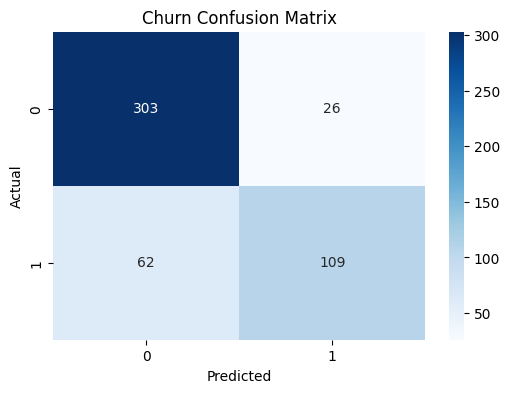

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       329
           1       0.81      0.64      0.71       171

    accuracy                           0.82       500
   macro avg       0.82      0.78      0.79       500
weighted avg       0.82      0.82      0.82       500



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, predictions)

#plotting
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Churn Confusion Matrix')
plt.show()

print(classification_report(y_test, predictions))

In [22]:
!pip install xgboost==1.7.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 49.5 MB/s  0:00:04m0:00:0100:01


In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X, y)
xgb_predictions = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")

XGBoost Accuracy: 81.80%


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


<Figure size 1000x600 with 0 Axes>

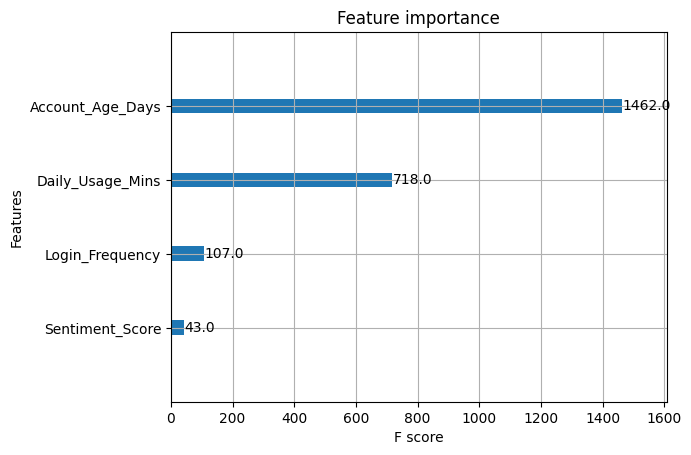

In [28]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot the importance of each of our 4 features
plt.figure(figsize=(10,6))
plot_importance(xgb_model)
plt.show()

In [29]:
# Create the new feature for Training data
df_train_clean['Usage_Intensity'] = df_train_clean['Daily_Usage_Mins'] / (df_train_clean['Account_Age_Days'] + 1)

# Redefine X with the new column
X = df_train_clean.drop('Churn', axis=1)

X.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Sentiment_Score,Usage_Intensity
0,790,1.0,28,0,0.035398
1,399,2.0,28,0,0.070000
2,646,2.0,110,1,0.170015
3,113,1.0,21,0,0.184211
4,322,1.0,7,-1,0.021672


In [31]:
# Create the same feature for Test data
df_test_clean['Usage_Intensity'] = df_test_clean['Daily_Usage_Mins'] / (df_test_clean['Account_Age_Days'] + 1)

# Redefine X_test
X_test = df_test_clean.drop('Churn', axis=1)

X_test.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Sentiment_Score,Usage_Intensity
0,269,2.0,43,0,0.159259
1,439,0.0,9,-1,0.020455
2,18,0.0,1,-1,0.052632
3,405,2.0,22,0,0.054187
4,24,2.0,88,1,3.520000


In [32]:
# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X, y)
xgb_predictions = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBoost Accuracy: 82.00%


In [33]:
# Re-tuning the "knobs" for better performance
tuned_xgb = XGBClassifier(
    n_estimators=200,      
    max_depth=4,           
    learning_rate=0.05,     
    subsample=0.8,         
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the tuned model
tuned_xgb.fit(X, y)

# Predict and Check Accuracy
tuned_predictions = tuned_xgb.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)

print(f"Tuned XGBoost Accuracy: {tuned_accuracy * 100:.2f}% 🏆")

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Tuned XGBoost Accuracy: 82.40% 🏆


In [34]:
from sklearn.metrics import classification_report

print("--- Tuned XGBoost Report ---")
print(classification_report(y_test, tuned_predictions))

--- Tuned XGBoost Report ---
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       329
           1       0.81      0.64      0.71       171

    accuracy                           0.82       500
   macro avg       0.82      0.78      0.79       500
weighted avg       0.82      0.82      0.82       500



In [35]:
# Instead of 0 or 1, let's get the raw probability (0.0 to 1.0)
probabilities = tuned_xgb.predict_proba(X_test)[:, 1]

# Set the alarm to trigger at 30% probability instead of 50%
lower_threshold_predictions = (probabilities > 0.3).astype(int)

# Check the new recall
from sklearn.metrics import classification_report
print("--- 30% Threshold Report ---")
print(classification_report(y_test, lower_threshold_predictions))

--- 30% Threshold Report ---
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       329
           1       0.73      0.67      0.70       171

    accuracy                           0.80       500
   macro avg       0.78      0.77      0.78       500
weighted avg       0.80      0.80      0.80       500

